X_train shape: (14241, 30, 16)


d:\RUL\DL\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 2690.0852 - val_loss: 1744.2122
Epoch 2/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1753.0514 - val_loss: 1745.1239
Epoch 3/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1752.8534 - val_loss: 1749.4150
Epoch 4/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1755.0348 - val_loss: 1752.7493
Epoch 5/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1753.1663 - val_loss: 1749.5933
Epoch 6/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1753.5060 - val_loss: 1744.2109
Epoch 7/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1753.3223 - val_loss: 1747.4231
Epoch 8/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1753.3961 - val_loss: 1751.8705
Epoch 9/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1753.2108 - val_loss: 1747.4917
Epoch 10/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1753.3907 - val_loss: 1751.8909
Epoch 11/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1753.20

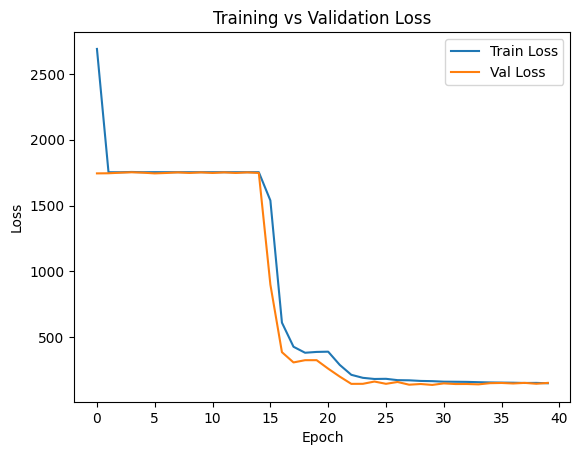

In [ ]:


import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt
import random

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# -------------------------
# LOAD DATA
# -------------------------
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

MAX_RUL  = 125.0

timesteps = X_train.shape[1]
features = X_train.shape[2]
print("X_train shape:", X_train.shape)

# -------------------------
# BUILD MODEL
# -------------------------
model_dense3 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(timesteps,features)),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model_dense3.compile(
    optimizer=Adam(learning_rate=0.005,clipnorm = 1.0),
    loss='mse'
)

model_dense3.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history2 = model_dense3.fit(
    X_train, y_train,
    epochs=80,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

y_train_predi = model_dense3.predict(X_train).flatten()
y_val_predi = model_dense3.predict(X_val).flatten()

train_rmsee = math.sqrt(mean_squared_error(y_train, y_train_predi))
val_rmsee = math.sqrt(mean_squared_error(y_val, y_val_predi))

print("\n=== LSTM RESULTS ===")
print("Train RMSE:", train_rmsee)
print("Val RMSE:", val_rmsee)


plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# -------------------------
# LOAD TEST DATA
# -------------------------
X_test_final = np.load("../data/processed/X_test_final.npy")
rul_test_final = np.load("../data/processed/rul_test.npy")

# -------------------------
# PREDICT
# -------------------------
y_test_pred = model_dense3.predict(X_test_final)*max

# -------------------------
# RMSE
# -------------------------
test_rmse = math.sqrt(mean_squared_error(rul_test_final, y_test_pred))

print("\n=== TEST RESULTS ===")
print("Test RMSE:", test_rmse)

# -------------------------
# SAMPLE PREDICTIONS
# -------------------------
print("\n=== SAMPLE TEST PREDICTIONS ===")
for i in range(10):
    print(f"Actual: {rul_test_final[i][0]} | Predicted: {round(y_test_pred[i][0],2)}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

=== TEST RESULTS ===
Test RMSE: 12.755058332344992

=== SAMPLE TEST PREDICTIONS ===
Actual: 112 | Predicted: 119.91999816894531
Actual: 98 | Predicted: 122.44999694824219
Actual: 69 | Predicted: 45.630001068115234
Actual: 82 | Predicted: 80.55999755859375
Actual: 91 | Predicted: 104.08999633789062
Actual: 93 | Predicted: 115.05999755859375
Actual: 91 | Predicted: 107.27999877929688
Actual: 95 | Predicted: 90.29000091552734
Actual: 111 | Predicted: 121.91999816894531
Actual: 96 | Predicted: 93.79000091552734
